In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:
import os
os.makedirs('images', exist_ok=True)

# Robust CSV read with encoding fallback and safe date parsing
encodings = ['utf-8', 'latin1', 'cp1252']
df = None
last_exc = None
for enc in encodings:
    try:
        tmp = pd.read_csv('Sample - Superstore.csv', encoding=enc, low_memory=False)
        # attempt to find and parse a date-like column
        date_cols = [c for c in tmp.columns if 'date' in c.lower()]
        if date_cols:
            tmp[date_cols[0]] = pd.to_datetime(tmp[date_cols[0]], errors='coerce')
        df = tmp
        print(f'Read file using encoding: {enc}')
        break
    except Exception as e:
        last_exc = e
if df is None:
    # final fallback: latin1 with replacement for invalid bytes
    df = pd.read_csv('Sample - Superstore.csv', encoding='latin1', errors='replace', low_memory=False)
    print('Fallback read with latin1 and replacement for invalid bytes')

# Normalize column names and ensure Sales is numeric
df.columns = [c.strip() for c in df.columns]
if 'Sales' in df.columns:
    df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
else:
    if 'sales' in [c.lower() for c in df.columns]:
        sales_col = [c for c in df.columns if c.lower()=='sales'][0]
        df['Sales'] = pd.to_numeric(df[sales_col], errors='coerce')

# Find a date column if present
date_cols = [c for c in df.columns if 'date' in c.lower()]
date_col = date_cols[0] if date_cols else None

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    ts = df.set_index(date_col)
    # Monthly sales
    monthly = ts['Sales'].resample('M').sum()
    plt.figure(figsize=(10,5))
    monthly.plot(marker='o')
    plt.title('Monthly Sales')
    plt.ylabel('Sales')
    plt.tight_layout()
    plt.savefig(os.path.join('images','monthly_sales.png'))
    plt.close()

    # Quarterly sales
    quarterly = ts['Sales'].resample('Q').sum()
    plt.figure(figsize=(8,5))
    quarterly.plot(kind='bar')
    plt.title('Quarterly Sales')
    plt.ylabel('Sales')
    plt.tight_layout()
    plt.savefig(os.path.join('images','quarterly_sales.png'))
    plt.close()
else:
    print('No date column found; skipping monthly/quarterly plots')

# Categorical sales by Category
if 'Category' in df.columns:
    cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
    plt.figure(figsize=(8,5))
    sns.barplot(data=cat, x='Category', y='Sales')
    plt.title('Sales by Category')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join('images','category_sales.png'))
    plt.close()
else:
    print('No Category column found; skipping category plot')

# Regional sales by Region
if 'Region' in df.columns:
    reg = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()
    plt.figure(figsize=(8,5))
    sns.barplot(data=reg, x='Region', y='Sales')
    plt.title('Sales by Region')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join('images','region_sales.png'))
    plt.close()
else:
    print('No Region column found; skipping region plot')

# Show a small sample
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [12]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

#### Data Cleaning

In [6]:
#checking for null values
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [13]:
df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Product ID','Ship Date', 'Ship Mode','Product Name','Product ID','Customer Name','Postal Code'], inplace=True)
df.head()

,Order Date,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,11/8/2016,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,11/8/2016,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,6/12/2016,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,10/11/2015,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,10/11/2015,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


#### Data Preprocessing

In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day
df['Quarter'] = df['Order Date'].dt.quarter
df.head()

,Order Date,Segment,Country,City,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Year,Month,Day,Quarter
0,2016-11-08,Consumer,United States,Henderson,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136,2016,11,8,4
1,2016-11-08,Consumer,United States,Henderson,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820,2016,11,8,4
2,2016-06-12,Corporate,United States,Los Angeles,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714,2016,6,12,2
3,2015-10-11,Consumer,United States,Fort Lauderdale,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310,2015,10,11,4
4,2015-10-11,Consumer,United States,Fort Lauderdale,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164,2015,10,11,4


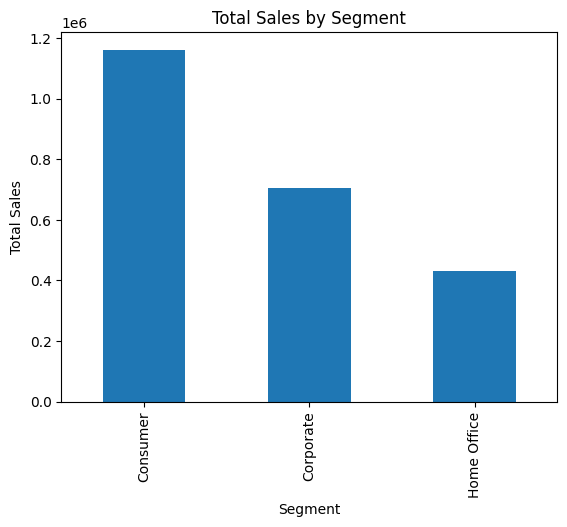

In [9]:
df.groupby('Segment')['Sales'].sum().plot(kind='bar')
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')   
plt.show()

#### Consumers are most customers to order.

#### Sales Analysis

Text(0.5, 1.0, 'Yearly Sales Trend')

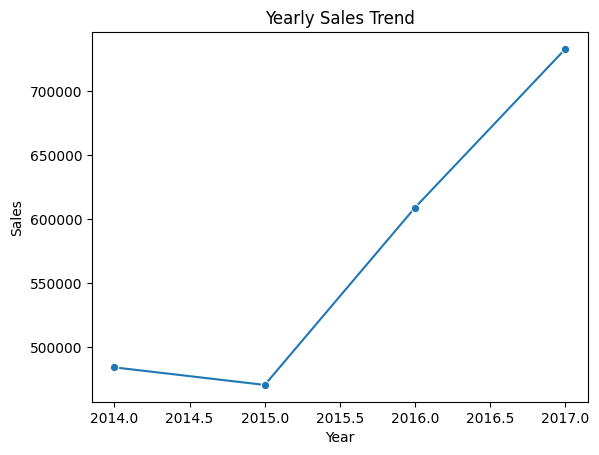

In [24]:
#yearly sales trend
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
sns.lineplot(data=yearly_sales, x='Year', y='Sales', marker='o')
plt.title('Yearly Sales Trend') 

#### The business is experiencing steady growth over time, indicating increasing customer demand and market expansion.

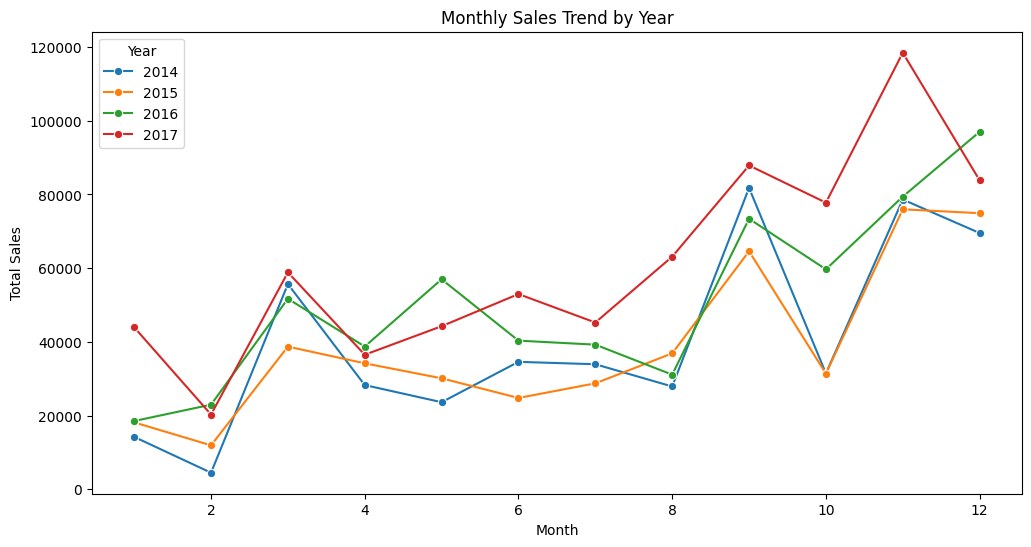

In [25]:
#Monthly sales trend year wise
monthly_sales = df.groupby(['Year', 'Month'])['Sales'].sum().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x='Month', y='Sales', hue='Year', marker='o', palette='tab10')
plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales')   
plt.legend(title='Year')
plt.show()    

Text(0.5, 1.0, 'Quarterly Sales Trend by Year')

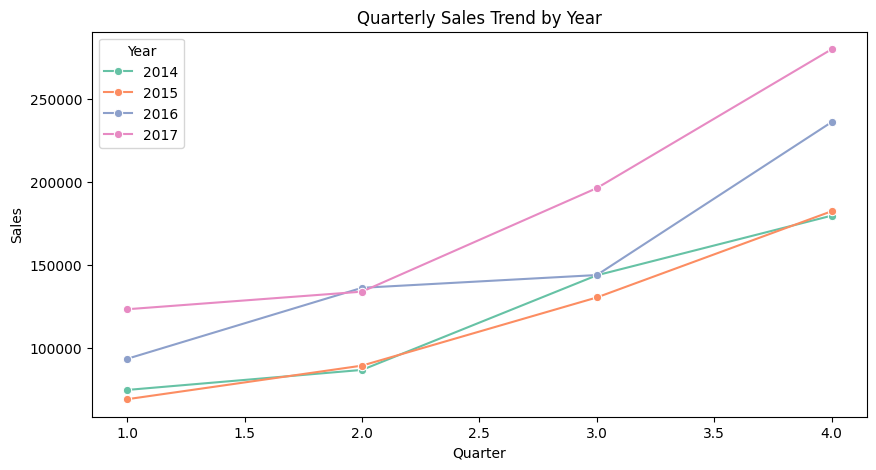

In [26]:
#quarterly sales trend
quarterly_sales = df.groupby(['Year', 'Quarter'])['Sales'].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=quarterly_sales, x='Quarter', y='Sales', hue='Year', marker='o', palette='Set2')
plt.title('Quarterly Sales Trend by Year')

C:\Users\rajuk\AppData\Local\Temp\ipykernel_9352\150569172.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regional_sales, x='Region', y='Sales', palette='pastel')


Text(0.5, 1.0, 'Total Sales by Region')

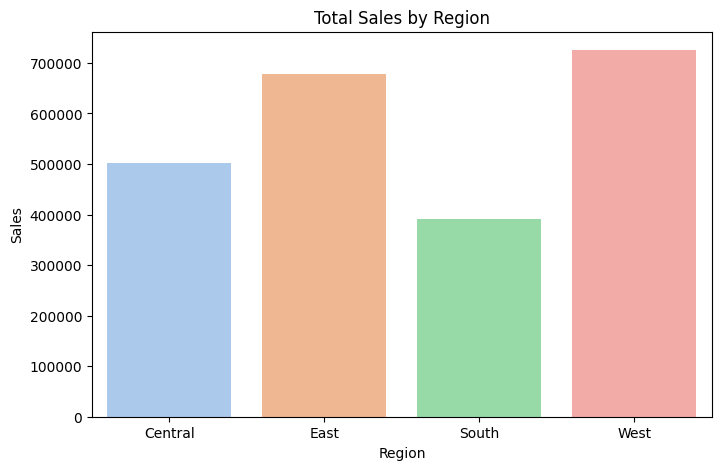

In [27]:
#Regional sales distribution
regional_sales = df.groupby('Region')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=regional_sales, x='Region', y='Sales', palette='pastel')
plt.title('Total Sales by Region')

#### West region sales are higher while south region sales are low.

Text(0.5, 1.0, 'Total Sales by Category')

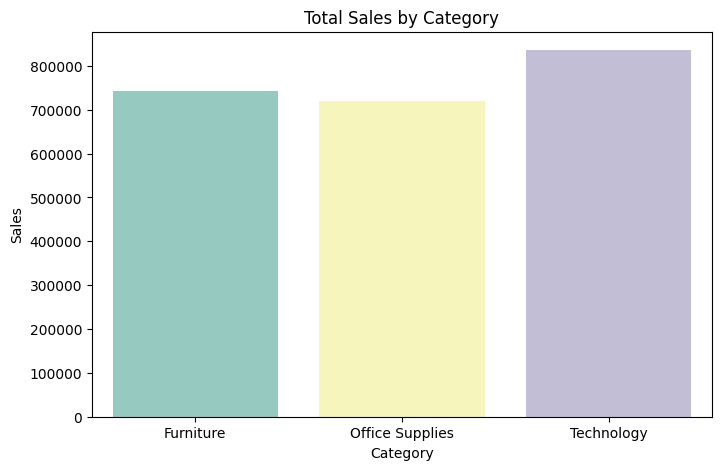

In [33]:
#category wise sales distribution
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=category_sales, x='Category', y='Sales', palette='Set3',hue='Category')
plt.title('Total Sales by Category')    

#### all categories sales are equally distributed.